In [ ]:
# Install Ultralytics YOLOv8
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.7 MB/s eta 0:00:00


**Below part is for testing a model on single images** 👍

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
model = YOLO("best1.pt")

In [ ]:
from google.colab import files
uploaded_image = files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
results = model("test.jpg")


image 1/1 /content/test.jpg: 640x480 11 cards, 12.1ms
Speed: 6.3ms preprocess, 12.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)



image 1/1 /content/test1.jpg: 640x384 1 symbol, 1 digit, 65.9ms
Speed: 3.2ms preprocess, 65.9ms inference, 17.3ms postprocess per image at shape (1, 3, 640, 384)


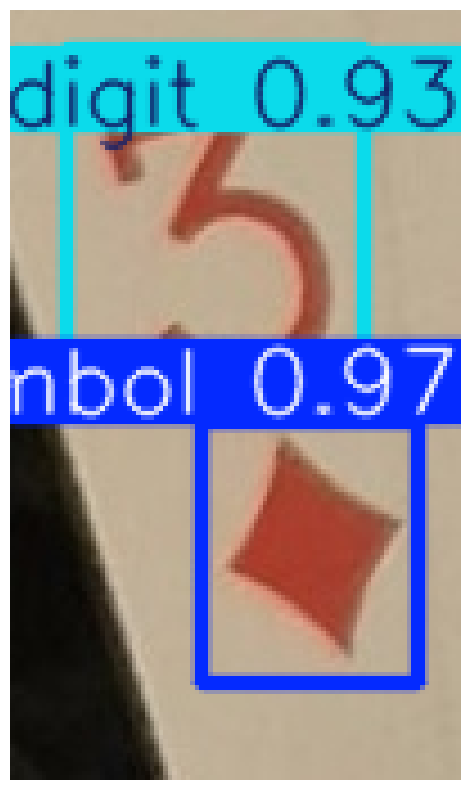

In [ ]:
results = model("test1.jpg")

# Get annotated image (NumPy array, BGR)
annotated_img = results[0].plot()

# Convert BGR → RGB for matplotlib
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [ ]:
# Step 1: Install YOLOv8 if not already
!pip install -q ultralytics

In [ ]:
# Step 2: Import libraries
import os
import zipfile
import cv2
from ultralytics import YOLO
from google.colab import files

In [ ]:
# Step 3: Upload ZIP file
print("Upload your ZIP file containing all images:")
uploaded = files.upload()  # select your zip

# Get the uploaded filename
zip_filename = list(uploaded.keys())[0]

# Extract ZIP
extract_folder = "input_images"
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Extracted all images to {extract_folder}")

Upload your ZIP file containing all images:


Saving croppedSD.zip to croppedSD.zip
Extracted all images to input_images


In [ ]:
# Step 4: Setup output folders
output_symbol_folder = "symbol"
output_digit_folder = "digit"

os.makedirs(output_symbol_folder, exist_ok=True)
os.makedirs(output_digit_folder, exist_ok=True)

In [ ]:
# Step 5: Load YOLOv8 model
model = YOLO("best1.pt")  # Replace with your YOLOv8 model file

In [ ]:
# Step 6: Function to crop and save detections
def crop_and_save(image_path, detections, img_counter):
    img = cv2.imread(image_path)

    for det in detections.boxes:
        cls_id = int(det.cls[0])
        conf = float(det.conf[0])
        bbox = det.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = map(int, bbox)
        crop = img[y1:y2, x1:x2]

        cls_name = model.names[cls_id]
        if cls_name.lower() == "symbol":
            save_path = os.path.join(output_symbol_folder, f"{cls_name}_{img_counter['symbol']}.jpg")
            img_counter['symbol'] += 1
        elif cls_name.lower() == "digit":
            save_path = os.path.join(output_digit_folder, f"{cls_name}_{img_counter['digit']}.jpg")
            img_counter['digit'] += 1
        else:
            continue

        # Optional: resize crop to 32x32 for CNN training
        crop = cv2.resize(crop, (32, 32))
        cv2.imwrite(save_path, crop)

In [ ]:
# Step 7: Iterate over all images in extracted folder
img_counter = {"symbol": 0, "digit": 0}

for root, dirs, files_in_dir in os.walk(extract_folder):
    for filename in files_in_dir:
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(root, filename)
            results = model(img_path)
            for result in results:
                crop_and_save(img_path, result, img_counter)

print("Cropping completed!")
print(f"Total symbol crops: {img_counter['symbol']}")
print(f"Total digit crops: {img_counter['digit']}")


image 1/1 /content/input_images/croppedSD/20251117_111506_obj10_class0.jpg: 288x640 1 symbol, 1 digit, 43.4ms
Speed: 1.3ms preprocess, 43.4ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /content/input_images/croppedSD/20251117_110844_obj11_class0.jpg: 576x640 3 symbols, 1 digit, 38.7ms
Speed: 2.1ms preprocess, 38.7ms inference, 1.2ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /content/input_images/croppedSD/20251117_105537_obj12_class15.jpg: 640x448 1 symbol, 1 digit, 40.7ms
Speed: 2.0ms preprocess, 40.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/input_images/croppedSD/20251117_103857_obj1_class0.jpg: 640x288 1 symbol, 1 digit, 44.8ms
Speed: 2.1ms preprocess, 44.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 288)

image 1/1 /content/input_images/croppedSD/20251117_110925_obj5_class0.jpg: 640x544 1 symbol, 1 digit, 42.9ms
Speed: 2.4ms preprocess, 42.9ms inference, 1.5ms postproc

In [ ]:
import shutil
from google.colab import files

# Function to zip a folder
def zip_folder(folder_name, zip_name):
    shutil.make_archive(zip_name, 'zip', folder_name)
    print(f"Zipped {folder_name} as {zip_name}.zip")

# Zip both folders
zip_folder("symbol", "symbol_crops")
zip_folder("digit", "digit_crops")

# Download both zips
files.download("symbol_crops.zip")
files.download("digit_crops.zip")

Zipped symbol as symbol_crops.zip
Zipped digit as digit_crops.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Below starts the training of my own classifier for symbol**

In [ ]:
from google.colab import files
import zipfile
import os

# Upload your dataset zip
print("Upload your dataset ZIP:")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]  # get the uploaded file

# Extract it
extract_folder = "dataset"
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Dataset extracted to {extract_folder}")

Upload your dataset ZIP:


Saving dataset.zip to dataset.zip
Dataset extracted to dataset


In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((32,32)),           # resize all images to 32x32
    transforms.RandomRotation(10),        # rotate ±10 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # slight brightness/contrast changes
    transforms.RandomHorizontalFlip(),    # flip horizontally
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

val_transforms = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

extract_folder="/content/dataset/dataset"

train_dataset = ImageFolder(root=os.path.join(extract_folder, "train"), transform=train_transforms)
val_dataset = ImageFolder(root=os.path.join(extract_folder, "val"), transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")  # should be ['club', 'diamond', 'heart', 'spade']

Training images: 364
Validation images: 85
Classes: ['club', 'diamond', 'heart', 'spade']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SymbolCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SymbolCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 128)  # 32x32 input → 8x8 after 2 pools
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SymbolCNN(num_classes=4)

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Acc: {correct/total:.4f}")

Epoch 1/10, Loss: 1.1243, Val Acc: 0.4941
Epoch 2/10, Loss: 0.6916, Val Acc: 0.4824
Epoch 3/10, Loss: 0.5767, Val Acc: 0.8706
Epoch 4/10, Loss: 0.4019, Val Acc: 0.9176
Epoch 5/10, Loss: 0.2762, Val Acc: 0.9529
Epoch 6/10, Loss: 0.2034, Val Acc: 0.9529
Epoch 7/10, Loss: 0.1533, Val Acc: 0.9647
Epoch 8/10, Loss: 0.1289, Val Acc: 0.9647
Epoch 9/10, Loss: 0.0993, Val Acc: 0.9294
Epoch 10/10, Loss: 0.1387, Val Acc: 0.9647


In [ ]:
torch.save(model.state_dict(), "symbol_classifier.pth")
print("Trained model saved as symbol_classifier.pth")

Trained model saved as symbol_classifier.pth


In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

# CNN class must be defined here
class SymbolCNN(torch.nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3,32,3,padding=1)
        self.conv2 = torch.nn.Conv2d(32,64,3,padding=1)
        self.pool = torch.nn.MaxPool2d(2,2)
        self.fc1 = torch.nn.Linear(64*8*8,128)
        self.fc2 = torch.nn.Linear(128,num_classes)
    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1,64*8*8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load model once
model = SymbolCNN(num_classes=4)
model.load_state_dict(torch.load("symbol_classifier.pth", map_location='cpu'))
model.eval()

# Preprocessing transforms
infer_transforms = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

# Class names
classes = ['club','diamond','heart','spade']

# Reusable prediction function
def predict_symbol(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = infer_transforms(img).unsqueeze(0)
    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = torch.max(outputs,1)
    return classes[pred.item()]

In [ ]:
symbol = predict_symbol("symbol_8.jpg")
print("Predicted symbol:", symbol)

Predicted symbol: spade


**Below is code for training model for recognizing symbol**






In [1]:
# make sure zip file is uploaded
import zipfile

with zipfile.ZipFile("dataset_rank.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Unzipped successfully")

Unzipped successfully


In [2]:
!ls dataset_rank/train

10  2  3  4  5	6  7  8  9  A  J  K  Q


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.RandomAffine(
        degrees=0,           # no rotation
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [12]:
train_dataset = datasets.ImageFolder(
    root="dataset_rank/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root="dataset_rank/val",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print("Class order:", class_names)

Class order: ['10', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'J', 'K', 'Q']


In [13]:
class RankCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [14]:
model = RankCNN(num_classes=len(class_names)).to(device)

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10, Loss: 62.7124, Val Acc: 0.3117
Epoch 2/10, Loss: 48.0548, Val Acc: 0.5195
Epoch 3/10, Loss: 28.7034, Val Acc: 0.7273
Epoch 4/10, Loss: 18.6055, Val Acc: 0.8701
Epoch 5/10, Loss: 13.9040, Val Acc: 0.9351
Epoch 6/10, Loss: 12.7963, Val Acc: 0.8831
Epoch 7/10, Loss: 10.5840, Val Acc: 0.9221
Epoch 8/10, Loss: 9.6550, Val Acc: 0.9221
Epoch 9/10, Loss: 6.2115, Val Acc: 0.9481
Epoch 10/10, Loss: 5.7869, Val Acc: 0.9221


In [17]:
torch.save(model.state_dict(), "rank_classifier.pth")
print("Model saved")

Model saved


In [18]:
with open("rank_classes.txt", "w") as f:
    for c in class_names:
        f.write(c + "\n")

print("Class order saved")

Class order saved


In [19]:
from google.colab import files

files.download("rank_classifier.pth")
files.download("rank_classes.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Below is code to run model and how to use it **

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# -------- Model definition (MUST match training) --------
class RankCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# -------- Load class order --------
with open("rank_classes.txt") as f:
    CLASSES = [line.strip() for line in f.readlines()]

# -------- Load model --------
model = RankCNN(num_classes=len(CLASSES))
model.load_state_dict(torch.load("rank_classifier.pth", map_location="cpu"))
model.eval()

# -------- Transforms (same as validation) --------
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -------- Prediction function --------
def predict_rank(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0)

    with torch.no_grad():
        outputs = model(x)
        _, pred = torch.max(outputs, 1)

    return CLASSES[pred.item()]

In [22]:


print(predict_rank("a.jpg"))

A
